# Example of usage of morpc-census for analysis

## ACS 5-year Estimates of Poverty and Race in the MORPC 15-County Region

This notebook walks through a realistic analysis scenario using `morpc-census`:

1. **Variable discovery** — find the Census tables for poverty status by race
2. **Fetch** — retrieve data for all 15 MORPC counties
3. **Snapshot** — compare poverty rates by race/ethnicity group, 2024, with reliability filtering
4. **Time series** — track changes in non-white poverty rates, 2014–2024
5. **Map** — choropleth of non-white poverty change by county

> **ACS 5-year note:** Each vintage year covers a 5-year period (e.g., 2024 covers 2020–2024). Consecutive years overlap by four years and are not statistically independent measurements.

In [147]:
from morpc_census import (
    Endpoint, Group, CensusAPI, DimensionTable, RaceDimensionTable,
    RACE_TABLE_MAP, HIGHLEVEL_DESC_TO_ID,
    fetch_geos_from_scope_sumlevel,
)
import pandas as pd
import numpy as np
import itables

## 1. Variable discovery


> ***Network required** — the cells below make live calls to the Census API.*

Start with an `Endpoint` and search `endpoint.groups` for tables related to the topic. We can think of an endpoint as specific survey and year/vintage.

> The ACS 5-year survey has hundreds of groups; filtering by keyword narrows the field quickly.

In [125]:
ep = Endpoint('acs/acs5', 2024)

ep.search_groups('poverty')

{'B05010': 'Ratio of Income to Poverty Level in the Past 12 Months by Nativity of Children Under 18 Years in Families and Subfamilies by Living Arrangements and Nativity of Parents',
 'B06012': 'Place of Birth by Poverty Status in the Past 12 Months in the United States',
 'B06012PR': 'Place of Birth by Poverty Status in the Past 12 Months in Puerto Rico',
 'B07012': 'Geographical Mobility in the Past Year by Poverty Status in the Past 12 Months for Current Residence in the United States',
 'B07012PR': 'Geographical Mobility in the Past Year by Poverty Status in the Past 12 Months for Current Residence in Puerto Rico',
 'B07412': 'Geographical Mobility in the Past Year by Poverty Status in the Past 12 Months for Residence 1 Year Ago in the United States',
 'B07412PR': 'Geographical Mobility in the Past Year by Poverty Status in the Past 12 Months for Residence 1 Year Ago in Puerto Rico',
 'B08122': 'Means of Transportation to Work by Poverty Status in the Past 12 Months',
 'B08522': 'M

**B17001** - *Poverty Status by Sex by Age* is the standard person-level poverty table.

We can look at the groups description and universe by creating a Group object.

In [28]:
g = Group(ep, 'B17001')
print(f"Description : {g.description}")
print(f"Universe    : {g.universe}")

Description : Poverty Status in the Past 12 Months by Sex by Age
Universe    : Population for whom poverty status is determined


To look at the rate of poverty we can call DimensionTable.percent() which will calculate the percent of each row based on the total.

The .drop() method allows us to drop unwanted dimension in the data, in this case sex and age. 

In [148]:
dim = DimensionTable(CensusAPI(ep, group=g, scope='region15').long).drop(['dim_2', 'dim_3']).percent()
itables.show(dim)

Loading ITables v2.7.3 from the internet... (need help?)


**B17001A-I** - *Poverty Status in the Past 12 Months by Sex by Age (by Race)* are race tables which separate poverty status by race. 

morpc-census allows us to call all of these table in the same format and concatenating them to compare across race.

In [77]:
race_groups = {value: Group(ep, f"B17001{key}") for key, value in RACE_TABLE_MAP.items()}

In [78]:
[v.description for k, v in race_groups.items()]

['Poverty Status in the Past 12 Months by Sex by Age (White Alone)',
 'Poverty Status in the Past 12 Months by Sex by Age (Black or African American Alone)',
 'Poverty Status in the Past 12 Months by Sex by Age (American Indian and Alaska Native Alone)',
 'Poverty Status in the Past 12 Months by Sex by Age (Asian Alone)',
 'Poverty Status in the Past 12 Months by Sex by Age (Native Hawaiian and Other Pacific Islander Alone)',
 'Poverty Status in the Past 12 Months by Sex by Age (Some Other Race Alone)',
 'Poverty Status in the Past 12 Months by Sex by Age (Two or More Races)',
 'Poverty Status in the Past 12 Months by Sex by Age (White Alone, Not Hispanic or Latino)',
 'Poverty Status in the Past 12 Months by Sex by Age (Hispanic or Latino)']

## 2. Fetching data

For the poverty-by-race snapshot we need two variables from each racial iteration table:

CensusAPI allows us to call a list of variables across groups. We can use this to call the variables needed from each race table.

| Variable | Meaning |
|---|---|
| `B17001X_001E` | Total population for whom poverty status is determined |
| `B17001X_002E` | Population with income below the poverty level |

The Census API returns a **margin of error** (MOE) alongside every estimate.
MOEs are reported at the 90% confidence level and appear in the `moe` column of `.long`.

In [149]:
race_vars = []
for code in RACE_TABLE_MAP:
    race_vars += [f'B17001{code}_001E', f'B17001{code}_001M', f'B17001{code}_002E', f'B17001{code}_002M']

race_api = CensusAPI(ep, 'region15', variables=race_vars)
itables.show(race_api.long)

Loading ITables v2.7.3 from the internet... (need help?)


## 3. Poverty by race — 2024 snapshot

For each racial group, the poverty rate is the share of people in that group whose income
falls below the federal poverty level:

morpc-census provides a DimensionTable and RaceDimensionTable to look at human-readable, wide format tables



In [151]:
wide = RaceDimensionTable(race_api.long).percent()
itables.show(wide, maxColumns=270)

Loading ITables v2.7.3 from the internet... (need help?)


In [152]:
itables.show(wide.melt().pivot_table(index=['geoidfq', 'name'], columns=['race', 'value_type'], values='value'))

/tmp/ipykernel_478215/905136670.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior


Loading ITables v2.7.3 from the internet... (need help?)


## 4. Non-white poverty over time (2014–2023)

To track change in poverty among non-white residents, subtract the White alone,
not Hispanic or Latino population (B17001H) from the all-persons total (B17001):

$$\text{non-white below poverty} = \text{B17001\_002} - \text{B17001H\_002}$$
$$\text{non-white total} = \text{B17001\_001} - \text{B17001H\_001}$$


> **Network required** — the loop below fetches five ACS vintage years.

In [153]:
ts_vars = ['B17001_001E', 'B17001_002E', 'B17001H_001E', 'B17001H_002E']

long_frames = []
for year in [2014, 2019, 2024]:
    ep_yr = Endpoint('acs/acs5', year)
    api   = CensusAPI(ep_yr, 'region15', variables=ts_vars)
    long_frames.append(api.long)

long_ts = pd.concat(long_frames, ignore_index=True)
itables.show(long_ts)

Loading ITables v2.7.3 from the internet... (need help?)


In [165]:
est_ts = long_ts.pivot_table(
    index=['geoidfq', 'name', 'reference_period'],
    columns='variable', values='estimate', aggfunc='first',
).reset_index()

nw_below = est_ts['B17001_002'] - est_ts['B17001H_002']
nw_total = est_ts['B17001_001'] - est_ts['B17001H_001']
est_ts['nw_rate'] = (nw_below / nw_total * 100).round(2)

rate_ts     = nw_below / nw_total

est_ts.pivot_table(
    index='reference_period', columns='name', values='nw_rate', aggfunc='first'
)

change = est_ts[['geoidfq', 'name', 'reference_period', 'nw_rate']].pivot(index=['geoidfq', 'name'], columns='reference_period', values='nw_rate')
itables.show(change)

Loading ITables v2.7.3 from the internet... (need help?)


## 5. Mapping the change

`fetch_geos_from_scope_sumlevel` returns a GeoDataFrame with county boundaries.
Merging it with the computed poverty change gives a ready-to-plot choropleth.

A diverging colormap (red = increase, blue = decrease) makes the direction of change
immediately readable.

In [166]:
change.columns = [f'rate_{yr}' for yr in change.columns]
change['change_pp'] = (change['rate_2024'] - change['rate_2014']).round(2)
change = change.reset_index()

In [185]:
change

,geoidfq,name,rate_2014,rate_2019,rate_2024,change_pp
0,0500000US39041,"Delaware County, Ohio",6.69,7.16,5.91,-0.78
1,0500000US39045,"Fairfield County, Ohio",13.91,10.82,9.77,-4.14
2,0500000US39047,"Fayette County, Ohio",27.58,35.26,15.76,-11.82
3,0500000US39049,"Franklin County, Ohio",29.53,25.32,20.69,-8.84
4,0500000US39073,"Hocking County, Ohio",29.39,23.06,34.68,5.29
5,0500000US39083,"Knox County, Ohio",18.10,25.35,15.31,-2.79
6,0500000US39089,"Licking County, Ohio",20.58,14.67,12.46,-8.12
7,0500000US39091,"Logan County, Ohio",36.55,20.15,12.29,-24.26
8,0500000US39097,"Madison County, Ohio",29.26,21.20,8.28,-20.98
9,0500000US39101,"Marion County, Ohio",32.65,27.13,32.11,-0.54


In [187]:
geos = fetch_geos_from_scope_sumlevel('region15')
geos = geos[['GEOIDFQ', 'geometry']].merge(change, left_on='GEOIDFQ', right_on='geoidfq', how='left')[['geoidfq', 'name', 'change_pp', 'geometry']].set_index('geoidfq')


Downloading: 100%|██████████████████████████| 1/1 [00:01<00:00, 1.02 requests/s]


In [188]:
geos

,name,change_pp,geometry
geoidfq,,,
0500000US39101,"Marion County, Ohio",-0.54,"POLYGON ((-83.18826 40.70214, -83.18888 40.702..."
0500000US39045,"Fairfield County, Ohio",-4.14,"POLYGON ((-82.49033 39.6617, -82.48837 39.6615..."
0500000US39159,"Union County, Ohio",-4.36,"POLYGON ((-83.17128 40.19808, -83.17137 40.201..."
0500000US39089,"Licking County, Ohio",-8.12,"POLYGON ((-82.46276 40.24515, -82.47418 40.245..."
0500000US39073,"Hocking County, Ohio",5.29,"POLYGON ((-82.40223 39.39023, -82.40107 39.390..."
0500000US39127,"Perry County, Ohio",-15.94,"POLYGON ((-82.47235 39.83884, -82.4724 39.8372..."
0500000US39141,"Ross County, Ohio",-7.41,"POLYGON ((-82.9982 39.48006, -82.9982 39.48036..."
0500000US39083,"Knox County, Ohio",-2.79,"POLYGON ((-82.18818 40.38335, -82.18795 40.387..."
0500000US39097,"Madison County, Ohio",-20.98,"POLYGON ((-83.20952 40.07514, -83.20788 40.092..."


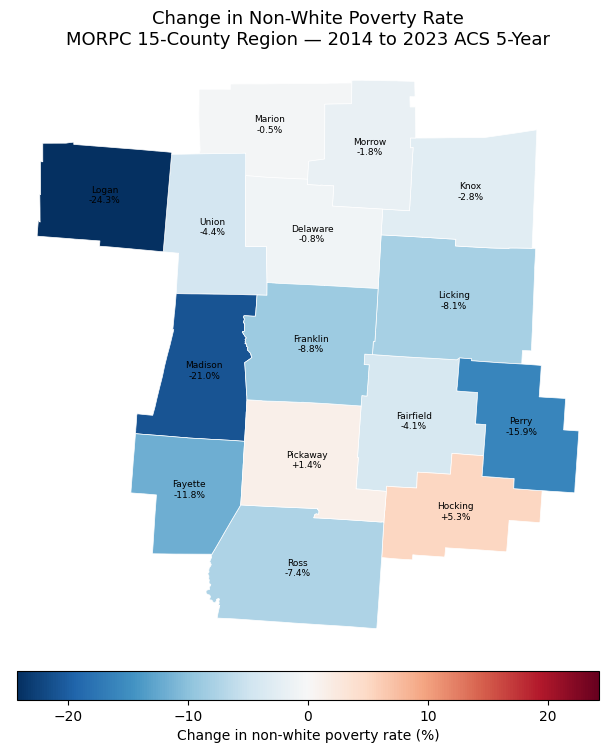

In [189]:
import matplotlib.pyplot as plt

max_abs = geos['change_pp'].abs().max()

fig, ax = plt.subplots(figsize=(10, 8))
geos.plot(
    column='change_pp',
    ax=ax,
    cmap='RdBu_r',
    vmin=-max_abs,
    vmax=max_abs,
    legend=True,
    legend_kwds={
        'label': 'Change in non-white poverty rate (%)',
        'orientation': 'horizontal',
        'shrink': 0.6,
        'pad': 0.02,
    },
    edgecolor='white',
    linewidth=0.5,
)

for _, row in geos.iterrows():
    cx = row.geometry.centroid.x
    cy = row.geometry.centroid.y
    label = row['name'].replace(', Ohio', '').replace(' County', '')
    val   = row['change_pp']
    ax.annotate(
        f"{label}\n{val:+.1f}%",
        (cx, cy),
        ha='center', va='center', fontsize=6.5, color='black',
    )

ax.set_title(
    'Change in Non-White Poverty Rate\nMORPC 15-County Region — 2014 to 2023 ACS 5-Year',
    fontsize=13,
)
ax.axis('off')
plt.tight_layout()
plt.show()